In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Loading the data, After the data prepration
with batch size of 32, and image size of (224,224) to be fit for the MobileNetV3

In [ ]:
training_DS = tf.keras.utils.image_dataset_from_directory(
    "train/",
    image_size=(224,224), batch_size=32,
    label_mode="binary"
)

Found 17259 files belonging to 2 classes.


In [3]:
val_DS=tf.keras.utils.image_dataset_from_directory(
    "val/",
    image_size=(224,224), batch_size=32,
    label_mode="binary"
)

Found 5351 files belonging to 2 classes.


In [4]:
test_DS=tf.keras.utils.image_dataset_from_directory(
    "test/",
    image_size=(224,224), batch_size=32,
    label_mode="binary"
)

Found 3711 files belonging to 2 classes.


In [5]:
for images, labels in training_DS.take(1):
    print("Batch shape:", images.shape)
    print("Labels shape:", labels.shape)

Batch shape: (32, 224, 224, 3)
Labels shape: (32, 1)


**next step is Augmentation code to help the model generalize well**

In [ ]:

data_aug=tf.keras.Sequential(
    [tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)]
)

**Loading OUR Model (MobileNetV3)**

In [ ]:
mobilenet=tf.keras.applications.MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"   #pretrained model (in our situation it's pretty much fixed weights) 
)
mobilenet.trainable = False   #Freaze the backbone (which is the layers and parameters of the pretrained model)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Here is how the model operates:

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))                #start by taking the pictures

x = data_aug(inputs)                                        #Applying the model Augmentation code (only in training)

x = tf.keras.applications.mobilenet_v3.preprocess_input(x)  #predefined preprocess inside the mobilenetV3

x = mobilenet(x, training=False)                            #Inserting the preprocessed photos to the model

x = tf.keras.layers.GlobalAveragePooling2D()(x)             #The first layer of our CNN AvgPool2D

x = tf.keras.layers.Dropout(0.3)(x)                         #The seacond layer is Dropout(0.3) to minimize memorizing

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x) #The last layer is Dense which gives the desicion

model = tf.keras.Model(inputs, outputs)                     #THE FINAL MODEL


## Compiler of the Model to reduce the loss-fuction Using "Adam"

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Callbacks prepration
which helps the model while fitting

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "fish_notfish_phase1.keras",
        monitor="val_loss",
        save_best_only=True
    )
]


## Fitting the model while keeping an eye on the performance

In [11]:
history = model.fit(
    training_DS,
    validation_data=val_DS,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 50s 87ms/step - accuracy: 0.7156 - loss: 0.5544 - val_accuracy: 0.9480 - val_loss: 0.2007
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 45s 84ms/step - accuracy: 0.9249 - loss: 0.2250 - val_accuracy: 0.9684 - val_loss: 0.1149
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9514 - loss: 0.1534 - val_accuracy: 0.9783 - val_loss: 0.0819
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 49s 91ms/step - accuracy: 0.9584 - loss: 0.1217 - val_accuracy: 0.9834 - val_loss: 0.0638
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 48s 89ms/step - accuracy: 0.9674 - loss: 0.0991 - val_accuracy: 0.9860 - val_loss: 0.0531
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9703 - loss: 0.0894 - val_accuracy: 0.9882 - val_loss: 0.0453
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 47s 88ms/step - accuracy: 0.9737 - loss: 0.0805 - val_accuracy: 0.9908 - val_loss: 0.0399
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 47s 87ms/step - accuracy: 0.9763 - loss: 0.0719 - 

Plotting the curves for the training & validation

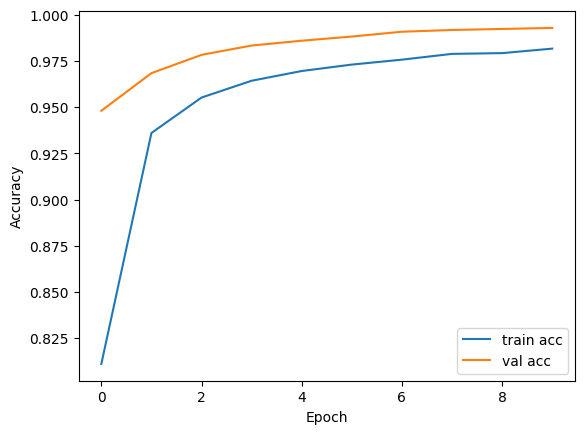

In [ ]:
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## evaluation on test data

In [ ]:
test_loss, test_acc = model.evaluate(test_DS)
print("Test accuracy:", test_acc)


116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9925 - loss: 0.0288
Test accuracy: 0.9924548864364624


## Confusion matrix

In [ ]:
y_true = []
y_pred = []

for images, labels in test_DS:
    preds = model.predict(images)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten()) #0.5 threshold even though at the main model we increased it to 0.7


In [15]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Not-Fish", "Fish"]))


Confusion Matrix:
 [[1744   17]
 [  11 1939]]

Classification Report:

              precision    recall  f1-score   support

    Not-Fish       0.99      0.99      0.99      1761
        Fish       0.99      0.99      0.99      1950

    accuracy                           0.99      3711
   macro avg       0.99      0.99      0.99      3711
weighted avg       0.99      0.99      0.99      3711



# READY TO BE USED 

---------


### Function to try the model on our uploaded photos

In [ ]:
def predict_single_image(image_path, model):
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.keras.applications.mobilenet_v3.preprocess_input(img_array)

    prediction = model.predict(img_array)[0][0]
    print(prediction)

    plt.imshow(img)
    plt.axis("off")

    if prediction < 0.5:
        print(f"🐟 Fish detected! (Confidence: {(1-prediction)*100:.2f}%)")
    else:
        print(f"🚫 Not a Fish (Confidence: {prediction*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
0.28480035
🐟 Fish detected! (Confidence: 71.52%)


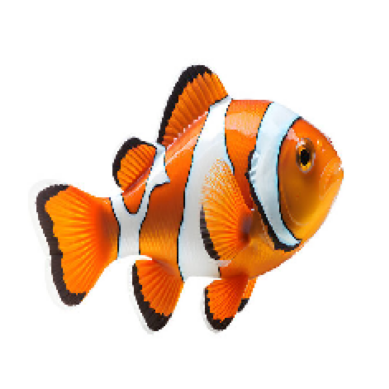

In [12]:
predict_single_image(
    "C:/Users/Yazeed/Desktop/occ.jpg",
    model
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
0.00083480374
🐟 Fish detected! (Confidence: 99.92%)


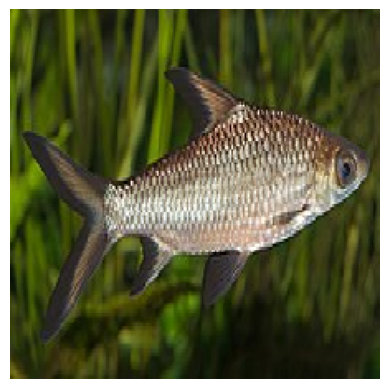

In [47]:
predict_single_image(
    "C:/Users/Yazeed/Desktop/mm.jpg",
    model
)

### saving the model

In [ ]:
model.save('Binary.keras')